In [2]:
import matplotlib.pyplot as plt
import numpy as np

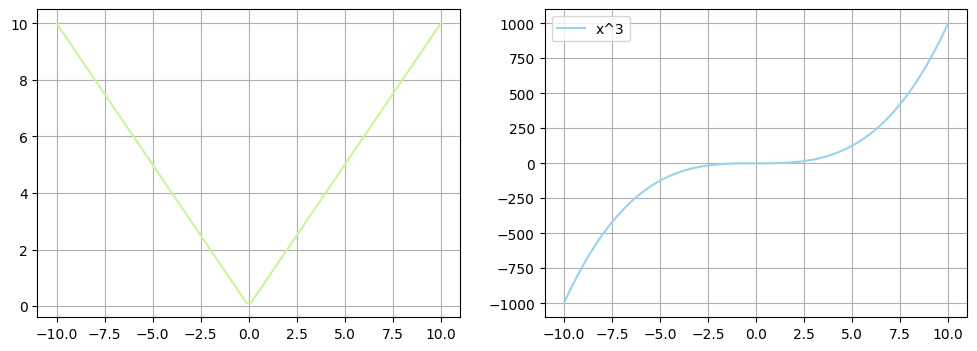

In [3]:
x = np.linspace(-10, 10, 100)
y_convex = abs(x)
y_nonconvex = x ** 3

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(x, y_convex, color = "#caf59a", label = '|x|')
ax[0].grid(True)

ax[1].plot(x, y_nonconvex, color = "#98d3ee", label = 'x^3')
ax[1].grid(True)

plt.legend()
plt.show()

Final m: 29.373387132916953, Final c: 86.32979159594913, Final Mean Square Error: 6.022236795400217


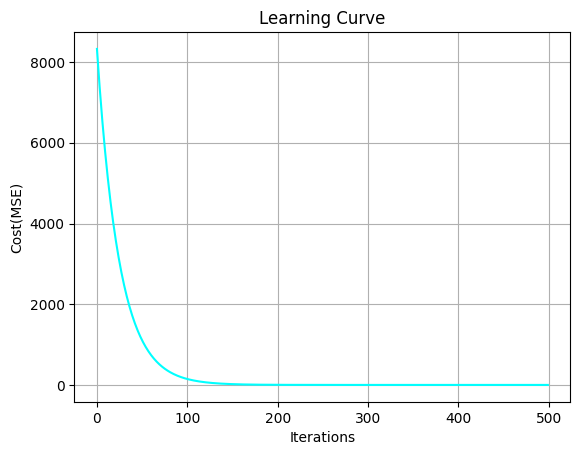

In [4]:
# Gradient Descent

# Sample Data
sizes =  np.array([1200, 1500, 1800, 2100, 2400, 2700])
prices = np.array([45, 60, 78, 90, 115, 130])

# Normalize features
sizes_norm = (sizes - sizes.mean())/ sizes.std()

# Parameters
m, c = 0, 0
learning_rate = 0.01
iterations = 500
n = float(len(sizes))

cost_history = []

# Gradient Descent Loop

for i in range(iterations):
  predictions = m * sizes_norm + c
  errors = prices - predictions

  # Gradients
  grad_m = (-2/n) * sum(sizes_norm * errors)
  grad_c = (-2/n) * sum(errors)

  # Update
  m = m - learning_rate * grad_m
  c = c- learning_rate * grad_c

  #Track cost
  mse = (errors**2).mean()
  cost_history.append(mse)

# print("Final m :",m , "Final c :",c, "Mean Square Error:", mse)
print(f"Final m: {m}, Final c: {c}, Final Mean Square Error: {mse}")
# print(f"Cost History: {cost_history}")

# Plot the learning curve to show how error reduces as training progesses

import matplotlib.pyplot as plt

plt.plot(range(iterations), cost_history, color="cyan")
plt.xlabel("Iterations")
plt.ylabel("Cost(MSE)")
plt.title("Learning Curve")
plt.grid(True)
plt.show()

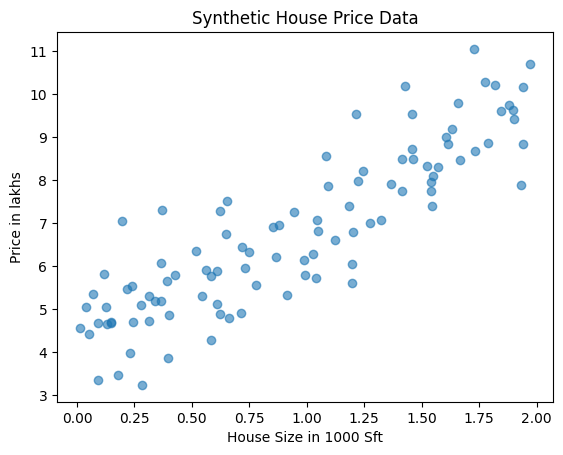

In [5]:
## Gradient Descent with Linear Regression
import numpy as np
import matplotlib.pyplot as plt

# Generate Synthetic data

np.random.seed(42)
X = 2 * np.random.rand(100,1)  #house Size (sqrft)
y = 4 + 3 *X + np.random.randn(100,1) #price = 4 + 3 * size + noise

plt.scatter(X, y, alpha=0.6)
plt.xlabel("House Size in 1000 Sft")
plt.ylabel("Price in lakhs")
plt.title("Synthetic House Price Data")
plt.show()

Epoch 50: MSE =  0.817, m =  2.926, c =  4.038


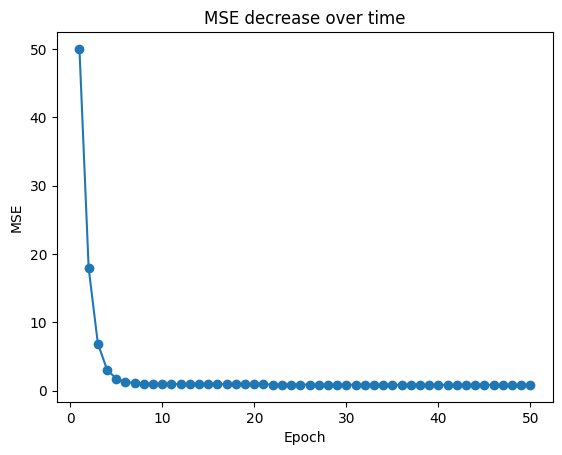

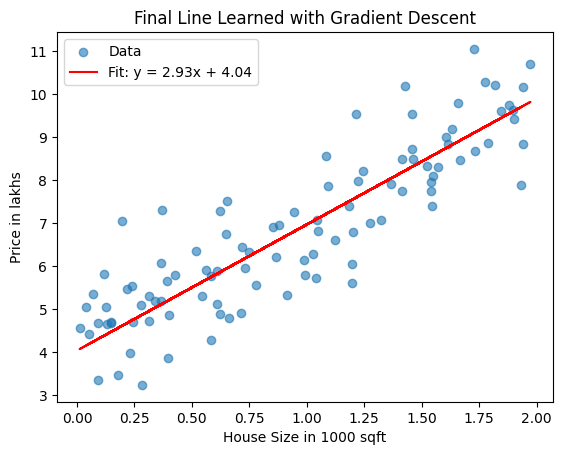

In [6]:
m, c= 0, 0

learning_rate = 0.1
num_epochs = 50 # steps

m_hist, c_hist, mse_hist = [], [], []

for epoch in range(num_epochs):
    y_pred = m * X + c

    mse = np.mean((y-y_pred) ** 2)

    dmse_dm = -2 * np.mean(X * (y - y_pred))
    dmse_dc = -2 * np.mean(y - y_pred)
    
    m = m - learning_rate * dmse_dm
    c = c - learning_rate * dmse_dc

    m_hist.append(m)
    c_hist.append(c)
    mse_hist.append(mse)

print(f"Epoch {epoch+1:02d}: MSE = {mse: .3f}, m = {m: .3f}, c = {c: .3f}")
plt.plot(range(1, num_epochs+1), mse_hist, marker='o')
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("MSE decrease over time")
plt.show()

plt.scatter(X, y, alpha=0.6, label="Data")
plt.plot(X, m*X + c, color="red", label=f"Fit: y = {m:.2f}x + {c:.2f}")
plt.xlabel("House Size in 1000 sqft")
plt.ylabel("Price in lakhs")
plt.title("Final Line Learned with Gradient Descent")
plt.legend()

plt.show()